In [1]:
import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.cluster import DBSCAN, KMeans
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import PowerTransformer


import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm

In [2]:
# Load the features

df_feat = pd.read_csv('../project_eeg/data/computed_features/mean_power_morlet_wavelets_with_delta_theta.csv')
df_feat.head()

,subject_name,epoch,cluster,time_period,frequency_range,mean_power
0,P149,1,CL1,"(-4, 0)",delta,6.613142e-09
1,P149,1,CL1,"(-4, 0)",theta,1.042548e-09
2,P149,1,CL1,"(-4, 0)",alpha,6.790457e-10
3,P149,1,CL1,"(-4, 0)",beta,2.765609e-10
4,P149,1,CL1,"(-4, 0)",lower gamma,8.716803e-11


In [3]:
# Create a new column that combines 'cluster', 'time_period', and 'frequency_range'
df_feat['combined'] = df_feat['cluster'].astype(str) + "_" + df_feat['time_period'].astype(str) + "_" + df_feat['frequency_range'].astype(str)

# Pivot the DataFrame
pivot_df = df_feat.pivot_table(index=['subject_name', 'epoch'], columns='combined', values='mean_power')

# Flatten the columns
pivot_df.columns = [col for col in pivot_df.columns]

# Reset the index
pivot_df = pivot_df.reset_index()

In [4]:
pivot_df.head()

,subject_name,epoch,"CL1_(-4, 0)_alpha","CL1_(-4, 0)_beta","CL1_(-4, 0)_delta","CL1_(-4, 0)_lower gamma","CL1_(-4, 0)_theta","CL1_(0, 5)_alpha","CL1_(0, 5)_beta","CL1_(0, 5)_delta",...,"CL6_(0, 5)_alpha","CL6_(0, 5)_beta","CL6_(0, 5)_delta","CL6_(0, 5)_lower gamma","CL6_(0, 5)_theta","CL6_(5, 10)_alpha","CL6_(5, 10)_beta","CL6_(5, 10)_delta","CL6_(5, 10)_lower gamma","CL6_(5, 10)_theta"
0,P101,1,9.088822e-10,2.072042e-10,3.287845e-09,7.816580e-11,1.656143e-09,1.303344e-09,2.988884e-10,5.732215e-09,...,1.537287e-09,3.561905e-10,4.908325e-09,6.962249e-11,1.729118e-09,1.202900e-09,3.501433e-10,5.478580e-09,5.951559e-11,1.423738e-09
1,P101,2,1.102854e-09,3.646768e-10,2.983556e-09,7.874124e-11,3.031881e-09,8.755720e-10,2.857535e-10,6.854427e-09,...,1.211884e-09,3.354284e-10,5.194283e-09,6.609093e-11,1.488689e-09,9.004423e-10,3.843510e-10,7.098802e-09,6.475551e-11,1.285826e-09
2,P101,3,1.119688e-09,3.283326e-10,5.693652e-09,6.170610e-11,1.940697e-09,1.635918e-09,3.778830e-10,6.764768e-09,...,1.663328e-09,4.766676e-10,4.582519e-09,6.637577e-11,1.316288e-09,1.119152e-09,3.557124e-10,2.524196e-09,5.997453e-11,1.505792e-09
3,P101,4,9.187232e-10,3.496927e-10,4.107768e-09,4.979888e-11,2.149611e-09,1.053823e-09,3.169192e-10,6.734609e-09,...,1.236335e-09,4.668531e-10,3.786341e-09,7.868001e-11,1.832124e-09,1.673658e-09,3.526146e-10,4.241283e-09,6.952896e-11,1.686248e-09
4,P101,5,1.066661e-09,3.380379e-10,2.458196e-09,5.411932e-11,1.880168e-09,1.419091e-09,3.662775e-10,6.364504e-09,...,1.190958e-09,4.125246e-10,5.845627e-09,8.286195e-11,1.713941e-09,9.169432e-10,3.606095e-10,4.427134e-09,7.090293e-11,1.798759e-09


In [6]:
pivot_df.to_csv('../project_eeg/data/features/mean_power_by_epochs_granular.csv', index=False)

In [7]:
# Transform features for the PCA analysis
# Create the transformer
transformer = PowerTransformer(method='yeo-johnson')

X_to_transform = pivot_df.drop(['subject_name','epoch'], axis=1)

# Fit the transformer to the data and transform the data
X_transformed_no_dummies = transformer.fit_transform(X_to_transform)
X_transformed_no_dummies = pd.DataFrame(X_transformed_no_dummies, columns=pivot_df.columns[2:])

In [8]:
# PCA Analysis

# Do PC decomposition
X_pca = PCA().fit(X_transformed_no_dummies)
X_pcs = X_pca.transform(X_transformed_no_dummies)
X_pcs = pd.DataFrame(X_pcs, 
                        columns=['PC'+str(i) for i in range(1, X_pcs.shape[1]+1)])

In [9]:
X_pca.explained_variance_

array([3.15363232e+01, 8.59256033e+00, 6.95388308e+00, 5.51583652e+00,
       5.01069719e+00, 3.17046812e+00, 2.97776033e+00, 2.20460622e+00,
       2.06471132e+00, 1.70778152e+00, 1.60178814e+00, 1.30909904e+00,
       1.15528413e+00, 1.09765186e+00, 1.07975979e+00, 9.40527833e-01,
       8.80080659e-01, 8.26237570e-01, 7.33664923e-01, 6.95227566e-01,
       6.54158315e-01, 6.15675452e-01, 5.54727423e-01, 4.75801887e-01,
       4.57670666e-01, 4.06201009e-01, 3.54748295e-01, 3.38616715e-01,
       3.21628682e-01, 3.04210063e-01, 2.91059368e-01, 2.55246925e-01,
       2.49397882e-01, 2.41448570e-01, 2.17611928e-01, 2.00092576e-01,
       1.91034927e-01, 1.89248481e-01, 1.85554821e-01, 1.75189289e-01,
       1.66892563e-01, 1.65180643e-01, 1.58703167e-01, 1.50337987e-01,
       1.43743508e-01, 1.39880789e-01, 1.33553100e-01, 1.24839115e-01,
       1.15218394e-01, 1.10553333e-01, 1.05299885e-01, 1.02647886e-01,
       1.02103862e-01, 9.26930705e-02, 7.99224130e-02, 7.89412158e-02,
      

In [10]:
# Horn's parallel analysis to determine the volatility contribution cut-off

def horn_parallel_analysis(shape, iters=12, percentile=95):
    pca = PCA(n_components=shape[1])
    eigenvals = []
    
    for i in range(iters):
        rdata = np.random.normal(0,1,size=shape)
        pca.fit(rdata)
        eigenvals.append(pca.explained_variance_)
    
    eigenvals = np.array(eigenvals)
    return np.percentile(eigenvals, percentile, axis=0)

X_pa=horn_parallel_analysis(pivot_df.iloc[:,2:].shape, percentile=95)

In [11]:
vectors_useful = np.sum(X_pca.explained_variance_>X_pa)

In [12]:
vectors_useful

13

In [13]:
# Explore the first PC vectors that have significant variance contribution

pc_col_names = ['PC'+str(x) for x in list(range(1,vectors_useful+1))]

draw_pc_useful = pd.DataFrame(X_pca.components_[0:vectors_useful].T, 
                         index=pivot_df.iloc[:,2:].columns,
                        columns=pc_col_names).sort_values(by='PC1',ascending=False)

### Same plot as above but excluding all features that have zero or very tiny PC holdings

draw_pc_top_pos = draw_pc_useful[(draw_pc_useful.T > 0.01).any()]
draw_pc_top_neg = draw_pc_useful[(draw_pc_useful.T < -0.01).any()]
draw_pc_nozeros = pd.concat([draw_pc_top_pos, draw_pc_top_neg])
draw_pc_nozeros = draw_pc_nozeros.drop_duplicates()

#draw_pc_nozeros.shape

In [14]:
# Visualize first 2 PCs

X_pc2 = PCA(n_components=2).fit(pivot_df.iloc[:,2:])
X_pc2s = X_pc2.transform(pivot_df.iloc[:,2:])
X_pc2s = pd.DataFrame(X_pc2s, 
                        columns=['PC'+str(i) for i in range(1, X_pc2s.shape[1]+1)])

In [15]:
X_pc2s

,PC1,PC2
0,-0.000001,-2.983345e-07
1,-0.000001,-2.965481e-07
2,-0.000001,-2.961725e-07
3,-0.000001,-2.972749e-07
4,-0.000001,-2.988189e-07
...,...,...
10704,-0.000001,-2.677490e-07
10705,-0.000001,-2.720810e-07
10706,-0.000001,-2.512206e-07
10707,-0.000001,-2.338965e-07


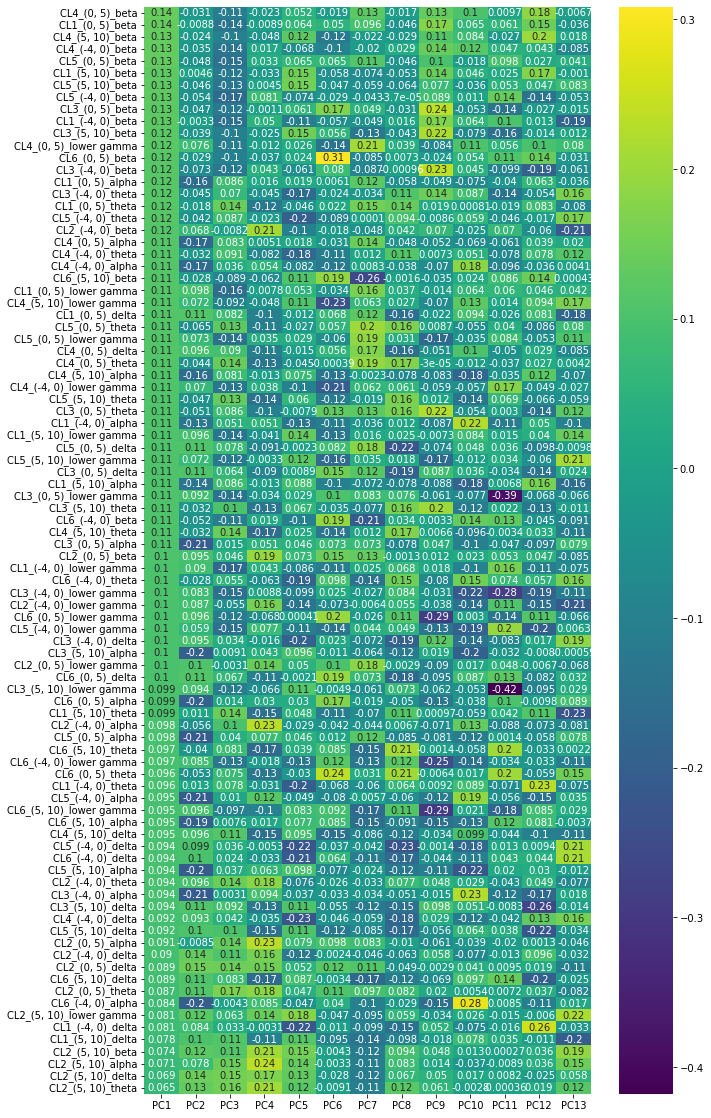

In [16]:
plt.figure(figsize=(10, 20))
sns.heatmap(draw_pc_nozeros, annot=True, cmap='viridis')
plt.show()

In [17]:
draw_pc_nozeros.shape

(90, 13)

In [18]:
pivot_df.shape

(10709, 92)

In [19]:
draw_pc_nozeros = draw_pc_nozeros.reset_index()
draw_pc_nozeros.head()

,index,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
0,"CL4_(0, 5)_beta",0.139209,-0.030595,-0.113634,-0.022868,0.051503,-0.018927,0.125196,-0.016766,0.133798,0.104088,0.009714,0.184374,-0.006661
1,"CL1_(0, 5)_beta",0.136072,-0.008753,-0.135120,-0.008907,0.064152,0.050448,0.096134,-0.046008,0.173422,0.065265,0.060613,0.145428,-0.035671
2,"CL4_(5, 10)_beta",0.134776,-0.024464,-0.104510,-0.048255,0.124487,-0.122472,-0.021936,-0.028635,0.112237,0.083862,-0.027307,0.199374,0.018333
3,"CL4_(-4, 0)_beta",0.134048,-0.034723,-0.135504,0.016810,-0.068415,-0.099825,-0.019978,0.029036,0.139646,0.120028,0.047092,0.042839,-0.084722
4,"CL5_(0, 5)_beta",0.132771,-0.048004,-0.148316,0.033444,0.064709,0.065283,0.114508,-0.045868,0.101299,-0.018498,0.098127,0.027492,0.041277


In [20]:
for i,col in enumerate(['cluster','time','freq']):
    draw_pc_nozeros[col] = [str(x).split("_")[i] for x in draw_pc_nozeros['index']]
draw_pc_nozeros.head()     

,index,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,cluster,time,freq
0,"CL4_(0, 5)_beta",0.139209,-0.030595,-0.113634,-0.022868,0.051503,-0.018927,0.125196,-0.016766,0.133798,0.104088,0.009714,0.184374,-0.006661,CL4,"(0, 5)",beta
1,"CL1_(0, 5)_beta",0.136072,-0.008753,-0.135120,-0.008907,0.064152,0.050448,0.096134,-0.046008,0.173422,0.065265,0.060613,0.145428,-0.035671,CL1,"(0, 5)",beta
2,"CL4_(5, 10)_beta",0.134776,-0.024464,-0.104510,-0.048255,0.124487,-0.122472,-0.021936,-0.028635,0.112237,0.083862,-0.027307,0.199374,0.018333,CL4,"(5, 10)",beta
3,"CL4_(-4, 0)_beta",0.134048,-0.034723,-0.135504,0.016810,-0.068415,-0.099825,-0.019978,0.029036,0.139646,0.120028,0.047092,0.042839,-0.084722,CL4,"(-4, 0)",beta
4,"CL5_(0, 5)_beta",0.132771,-0.048004,-0.148316,0.033444,0.064709,0.065283,0.114508,-0.045868,0.101299,-0.018498,0.098127,0.027492,0.041277,CL5,"(0, 5)",beta


In [21]:
draw_pc_nozeros.columns[1:-3]

Index(['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10',
       'PC11', 'PC12', 'PC13'],
      dtype='object')

In [22]:
for i,col in enumerate(draw_pc_nozeros.columns[1:-3]):
    pc_abs = draw_pc_nozeros[[col, 'cluster','time','freq']].copy()
    pc_abs['PC_abs'] = [np.abs(x) for x in pc_abs[col]]
    pc_ordered = pc_abs.sort_values(by='PC_abs', ascending=False)
    pc_ordered['rank'] = range(1, len(pc_ordered) + 1)
    
    print("------------")
    print(col)
    print(pc_ordered.groupby('cluster')['rank'].mean())
    print(pc_ordered.groupby('freq')['rank'].mean())
    print(pc_ordered.groupby('time')['rank'].mean())

------------
PC1
cluster
CL1    36.866667
CL2    70.666667
CL3    40.866667
CL4    27.933333
CL5    39.933333
CL6    56.733333
Name: rank, dtype: float64
freq
alpha          53.888889
beta           17.277778
delta          65.444444
lower gamma    45.055556
theta          45.833333
Name: rank, dtype: float64
time
(-4, 0)    46.866667
(0, 5)     36.166667
(5, 10)    53.466667
Name: rank, dtype: float64
------------
PC2
cluster
CL1    52.933333
CL2    35.933333
CL3    43.666667
CL4    52.000000
CL5    43.933333
CL6    44.533333
Name: rank, dtype: float64
freq
alpha          18.166667
beta           68.944444
delta          29.611111
lower gamma    45.000000
theta          65.777778
Name: rank, dtype: float64
time
(-4, 0)    48.266667
(0, 5)     43.733333
(5, 10)    44.500000
Name: rank, dtype: float64
------------
PC3
cluster
CL1    36.200000
CL2    39.000000
CL3    52.333333
CL4    44.066667
CL5    41.066667
CL6    60.333333
Name: rank, dtype: float64
freq
alpha          67.222222
beta